# Solving the 1D Heat Equation with PyTorch

This notebook demonstrates how to solve the **1D heat equation** using:
- **Finite Difference Method** for spatial discretization
- **Crank-Nicolson Method** for time stepping
- **Neumann Boundary Conditions** (insulated ends)

We'll use PyTorch for tensor operations and linear algebra, with NumPy as a fallback where needed.

## 1. Theory

### The Heat Equation

The 1D heat equation describes how temperature $u(x, t)$ evolves over time in a one-dimensional rod:

$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}$$

where:
- $u(x, t)$ is the temperature at position $x$ and time $t$
- $\alpha$ is the **thermal diffusivity** (how fast heat spreads)

### Finite Difference for Space

We approximate the second derivative using central differences:

$$\frac{\partial^2 u}{\partial x^2} \approx \frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta x^2}$$

### Crank-Nicolson Method for Time

The Crank-Nicolson method is **unconditionally stable** and **second-order accurate** in both space and time. It averages the spatial derivative between the current time step $n$ and the next time step $n+1$:

$$\frac{u_i^{n+1} - u_i^n}{\Delta t} = \frac{\alpha}{2} \left( \frac{u_{i+1}^{n+1} - 2u_i^{n+1} + u_{i-1}^{n+1}}{\Delta x^2} + \frac{u_{i+1}^{n} - 2u_i^{n} + u_{i-1}^{n}}{\Delta x^2} \right)$$

Defining $r = \frac{\alpha \Delta t}{2 \Delta x^2}$, we can rearrange to get:

$$-r \cdot u_{i-1}^{n+1} + (1 + 2r) \cdot u_i^{n+1} - r \cdot u_{i+1}^{n+1} = r \cdot u_{i-1}^{n} + (1 - 2r) \cdot u_i^{n} + r \cdot u_{i+1}^{n}$$

This forms a **tridiagonal linear system**: $A \cdot u^{n+1} = B \cdot u^n$

### Neumann Boundary Conditions

Neumann boundary conditions specify the **derivative** at the boundaries:

$$\frac{\partial u}{\partial x}\bigg|_{x=0} = 0 \quad \text{and} \quad \frac{\partial u}{\partial x}\bigg|_{x=L} = 0$$

This represents **insulated ends** where no heat flows in or out. We implement this using ghost points.

## 2. Setup and Imports

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Set default dtype for better precision
torch.set_default_dtype(torch.float64)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.10.0+cu128


## 3. Problem Parameters

Let's define our physical problem: a rod of length $L$ with an initial temperature distribution.

In [2]:
# Physical parameters
L = 1.0              # Length of the rod [m]
alpha = 0.01         # Thermal diffusivity [m^2/s]
T_total = 5.0        # Total simulation time [s]

# Discretization parameters
Nx = 1000              # Number of spatial points
Nt = 500             # Number of time steps

# Derived quantities
dx = L / (Nx - 1)    # Spatial step size
dt = T_total / Nt    # Time step size
r = alpha * dt / (2 * dx**2)  # Crank-Nicolson parameter

print(f"Spatial step (dx): {dx:.6f} m")
print(f"Time step (dt): {dt:.6f} s")
print(f"Crank-Nicolson parameter (r): {r:.6f}")
print(f"\nNote: Crank-Nicolson is unconditionally stable for any r > 0")

Spatial step (dx): 0.001001 m
Time step (dt): 0.010000 s
Crank-Nicolson parameter (r): 49.900050

Note: Crank-Nicolson is unconditionally stable for any r > 0


## 4. Building the Matrices

We need to construct two tridiagonal matrices:
- **Matrix A** (implicit, left-hand side): coefficients for $u^{n+1}$
- **Matrix B** (explicit, right-hand side): coefficients for $u^n$

The Neumann boundary conditions modify the first and last rows.

In [3]:
def build_crank_nicolson_matrices(Nx, r, device='cpu'):
    """
    Build the A and B matrices for the Crank-Nicolson scheme
    with Neumann (zero-flux) boundary conditions.

    A * u^{n+1} = B * u^n

    Parameters:
    -----------
    Nx : int
        Number of spatial grid points
    r : float
        Crank-Nicolson parameter: alpha * dt / (2 * dx^2)
    device : str
        PyTorch device ('cpu' or 'cuda')

    Returns:
    --------
    A, B : torch.Tensor
        Tridiagonal matrices of shape (Nx, Nx)
    """
    # Initialize matrices with zeros
    A = torch.zeros((Nx, Nx), device=device)
    B = torch.zeros((Nx, Nx), device=device)

    # Fill the interior points (standard Crank-Nicolson stencil)
    for i in range(1, Nx - 1):
        # Matrix A (implicit): -r * u_{i-1}^{n+1} + (1+2r) * u_i^{n+1} - r * u_{i+1}^{n+1}
        A[i, i-1] = -r
        A[i, i] = 1 + 2*r
        A[i, i+1] = -r

        # Matrix B (explicit): r * u_{i-1}^n + (1-2r) * u_i^n + r * u_{i+1}^n
        B[i, i-1] = r
        B[i, i] = 1 - 2*r
        B[i, i+1] = r

    # Neumann BC at x = 0: du/dx = 0
    # Using ghost point: u_{-1} = u_1, so the equation becomes:
    # (1+2r) * u_0^{n+1} - 2r * u_1^{n+1} = (1-2r) * u_0^n + 2r * u_1^n
    A[0, 0] = 1 + 2*r
    A[0, 1] = -2*r
    B[0, 0] = 1 - 2*r
    B[0, 1] = 2*r

    # Neumann BC at x = L: du/dx = 0
    # Using ghost point: u_{Nx} = u_{Nx-2}, so the equation becomes:
    # -2r * u_{Nx-2}^{n+1} + (1+2r) * u_{Nx-1}^{n+1} = 2r * u_{Nx-2}^n + (1-2r) * u_{Nx-1}^n
    A[Nx-1, Nx-2] = -2*r
    A[Nx-1, Nx-1] = 1 + 2*r
    B[Nx-1, Nx-2] = 2*r
    B[Nx-1, Nx-1] = 1 - 2*r

    return A, B

# Build the matrices
A, B = build_crank_nicolson_matrices(Nx, r, device)

print("Matrix A (first 6x6 block):")
print(A[:6, :6])
print("\nMatrix B (first 6x6 block):")
print(B[:6, :6])

Matrix A (first 6x6 block):
tensor([[100.8001, -99.8001,   0.0000,   0.0000,   0.0000,   0.0000],
        [-49.9001, 100.8001, -49.9001,   0.0000,   0.0000,   0.0000],
        [  0.0000, -49.9001, 100.8001, -49.9001,   0.0000,   0.0000],
        [  0.0000,   0.0000, -49.9001, 100.8001, -49.9001,   0.0000],
        [  0.0000,   0.0000,   0.0000, -49.9001, 100.8001, -49.9001],
        [  0.0000,   0.0000,   0.0000,   0.0000, -49.9001, 100.8001]],
       device='cuda:0')

Matrix B (first 6x6 block):
tensor([[-98.8001,  99.8001,   0.0000,   0.0000,   0.0000,   0.0000],
        [ 49.9001, -98.8001,  49.9001,   0.0000,   0.0000,   0.0000],
        [  0.0000,  49.9001, -98.8001,  49.9001,   0.0000,   0.0000],
        [  0.0000,   0.0000,  49.9001, -98.8001,  49.9001,   0.0000],
        [  0.0000,   0.0000,   0.0000,  49.9001, -98.8001,  49.9001],
        [  0.0000,   0.0000,   0.0000,   0.0000,  49.9001, -98.8001]],
       device='cuda:0')


## 5. Initial Condition

Let's use a Gaussian pulse centered in the middle of the rod. This represents a localized heat source.

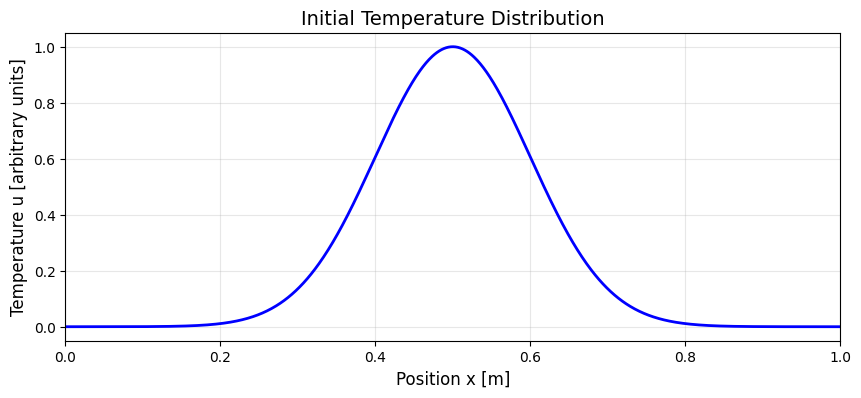

In [4]:
def initial_condition(x, condition_type='gaussian'):
    """
    Define the initial temperature distribution.

    Parameters:
    -----------
    x : torch.Tensor
        Spatial coordinates
    condition_type : str
        Type of initial condition: 'gaussian', 'step', or 'sine'

    Returns:
    --------
    u0 : torch.Tensor
        Initial temperature distribution
    """
    L = x[-1] - x[0]
    x0 = (x[0] + x[-1]) / 2  # Center of the domain

    if condition_type == 'gaussian':
        # Gaussian pulse centered at x0
        sigma = L / 10  # Width of the Gaussian
        return torch.exp(-((x - x0) ** 2) / (2 * sigma ** 2))

    elif condition_type == 'step':
        # Step function (hot region in the middle)
        return torch.where((x > 0.3 * L) & (x < 0.7 * L),
                          torch.ones_like(x),
                          torch.zeros_like(x))

    elif condition_type == 'sine':
        # Sinusoidal distribution
        return torch.sin(torch.pi * x / L)

    else:
        raise ValueError(f"Unknown condition type: {condition_type}")

# Create spatial grid
x = torch.linspace(0, L, Nx, device=device)

# Set initial condition
u0 = initial_condition(x, condition_type='gaussian')

# Visualize initial condition
plt.figure(figsize=(10, 4))
plt.plot(x.cpu().numpy(), u0.cpu().numpy(), 'b-', linewidth=2)
plt.xlabel('Position x [m]', fontsize=12)
plt.ylabel('Temperature u [arbitrary units]', fontsize=12)
plt.title('Initial Temperature Distribution', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim([0, L])
plt.show()

## 6. Time-Stepping Solver

Now we implement the main solver loop. At each time step, we solve the linear system $A \cdot u^{n+1} = B \cdot u^n$.

In [5]:
def solve_heat_equation(A, B, u0, Nt, save_every=1):
    """
    Solve the 1D heat equation using Crank-Nicolson method.

    Parameters:
    -----------
    A : torch.Tensor
        Left-hand side matrix (implicit)
    B : torch.Tensor
        Right-hand side matrix (explicit)
    u0 : torch.Tensor
        Initial condition
    Nt : int
        Number of time steps
    save_every : int
        Save solution every N steps (for memory efficiency)

    Returns:
    --------
    u_history : torch.Tensor
        Solution at saved time steps, shape (n_saved, Nx)
    """
    Nx = u0.shape[0]
    n_saved = Nt // save_every + 1

    # Pre-allocate storage for solution history
    u_history = torch.zeros((n_saved, Nx), device=u0.device)
    u_history[0] = u0.clone()

    # Current solution
    u = u0.clone()

    # Pre-compute LU decomposition of A for efficiency
    # PyTorch's torch.linalg.solve uses optimized algorithms internally

    save_idx = 1
    for n in range(1, Nt + 1):
        # Compute right-hand side: b = B @ u
        b = B @ u

        # Solve the linear system: A @ u_new = b
        # Using torch.linalg.solve for the linear system
        u = torch.linalg.solve(A, b)

        # Save solution at specified intervals
        if n % save_every == 0:
            u_history[save_idx] = u.clone()
            save_idx += 1

    return u_history

# Solve the heat equation
print("Solving the heat equation...")
save_every = max(1, Nt // 100)  # Save ~100 frames for animation
u_history = solve_heat_equation(A, B, u0, Nt, save_every=save_every)
print(f"Done! Saved {u_history.shape[0]} time snapshots.")

Solving the heat equation...
Done! Saved 101 time snapshots.


## 7. Visualizing the Results

Let's first look at some snapshots of the temperature distribution at different times.

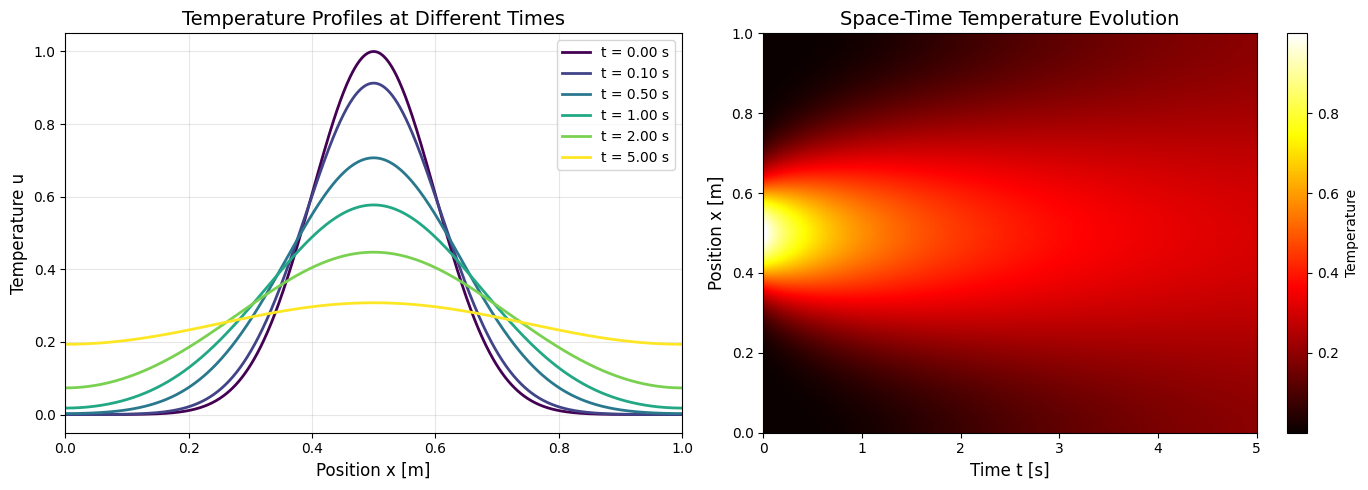

In [6]:
# Convert to numpy for plotting
x_np = x.cpu().numpy()
u_history_np = u_history.cpu().numpy()

# Time array for saved snapshots
t_saved = np.linspace(0, T_total, u_history_np.shape[0])

# Plot snapshots at different times
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Temperature profiles at different times
ax1 = axes[0]
times_to_plot = [0, 0.1, 0.5, 1.0, 2.0, 5.0]  # Times in seconds
colors = plt.cm.viridis(np.linspace(0, 1, len(times_to_plot)))

for t_target, color in zip(times_to_plot, colors):
    idx = np.argmin(np.abs(t_saved - t_target))
    actual_t = t_saved[idx]
    ax1.plot(x_np, u_history_np[idx], color=color, linewidth=2,
             label=f't = {actual_t:.2f} s')

ax1.set_xlabel('Position x [m]', fontsize=12)
ax1.set_ylabel('Temperature u', fontsize=12)
ax1.set_title('Temperature Profiles at Different Times', fontsize=14)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, L])

# Right plot: Space-time heatmap
ax2 = axes[1]
im = ax2.imshow(u_history_np.T, aspect='auto', origin='lower',
                extent=[0, T_total, 0, L], cmap='hot')
ax2.set_xlabel('Time t [s]', fontsize=12)
ax2.set_ylabel('Position x [m]', fontsize=12)
ax2.set_title('Space-Time Temperature Evolution', fontsize=14)
plt.colorbar(im, ax=ax2, label='Temperature')

plt.tight_layout()
plt.show()

## 8. Conservation Check

With Neumann boundary conditions (no heat flux at boundaries), the total heat in the system should be **conserved**. Let's verify this:

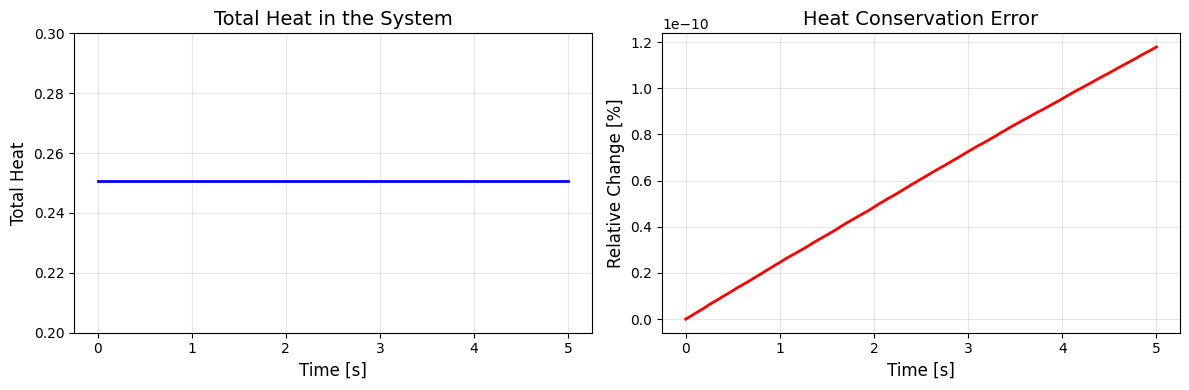

Initial total heat: 0.2506626837
Final total heat: 0.2506626837
Maximum relative error: 1.18e-10 %


In [7]:
# Compute total heat (integral of temperature) at each saved time step
# Using trapezoidal rule for integration (np.trapezoid in NumPy 2.0+)
total_heat = np.trapezoid(u_history_np, x_np, axis=1)

# Relative change from initial
relative_change = (total_heat - total_heat[0]) / total_heat[0] * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Total heat over time
axes[0].plot(t_saved, total_heat, 'b-', linewidth=2)
axes[0].set_xlabel('Time [s]', fontsize=12)
axes[0].set_ylabel('Total Heat', fontsize=12)
axes[0].set_title('Total Heat in the System', fontsize=14)
axes[0].grid(True, alpha=0.3)
# Adjust y-axis range and ticks
axes[0].set_ylim([0.2, 0.3])  # or whatever range you want


# Relative change
axes[1].plot(t_saved, relative_change, 'r-', linewidth=2)
axes[1].set_xlabel('Time [s]', fontsize=12)
axes[1].set_ylabel('Relative Change [%]', fontsize=12)
axes[1].set_title('Heat Conservation Error', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Initial total heat: {total_heat[0]:.10f}")
print(f"Final total heat: {total_heat[-1]:.10f}")
print(f"Maximum relative error: {np.max(np.abs(relative_change)):.2e} %")

## 9. Animation

Now let's create an animation showing how the temperature profile evolves over time. This is the most intuitive way to understand heat diffusion!

In [8]:
def create_animation(x, u_history, t_array, interval=50):
    """
    Create an animation of the temperature evolution.

    Parameters:
    -----------
    x : ndarray
        Spatial coordinates
    u_history : ndarray
        Temperature history, shape (n_times, n_x)
    t_array : ndarray
        Time values corresponding to u_history
    interval : int
        Milliseconds between frames

    Returns:
    --------
    anim : FuncAnimation
        Matplotlib animation object
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    # Initialize the line
    line, = ax.plot([], [], 'b-', linewidth=2.5)

    # Plot initial condition as reference (faded)
    ax.plot(x, u_history[0], 'k--', alpha=0.3, linewidth=1.5, label='Initial')

    # Formatting
    ax.set_xlim(x[0], x[-1])
    ax.set_ylim(-0.05, 1.1 * np.max(u_history))
    ax.set_xlabel('Position x [m]', fontsize=14)
    ax.set_ylabel('Temperature u', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=12)

    # Time text
    time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontsize=14,
                        verticalalignment='top', fontfamily='monospace',
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Title
    ax.set_title('1D Heat Equation: Temperature Evolution\n(Neumann BCs - Insulated Ends)',
                 fontsize=14)

    def init():
        line.set_data([], [])
        time_text.set_text('')
        return line, time_text

    def animate(frame):
        line.set_data(x, u_history[frame])
        time_text.set_text(f't = {t_array[frame]:.3f} s')
        return line, time_text

    anim = FuncAnimation(fig, animate, init_func=init,
                        frames=len(t_array), interval=interval,
                        blit=True, repeat=True)

    plt.close(fig)  # Prevent static display
    return anim

# Create and display the animation
print("Creating animation...")
anim = create_animation(x_np, u_history_np, t_saved, interval=50)
HTML(anim.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

## 10. Comparison with Different Initial Conditions

Let's see how different initial conditions evolve. With Neumann BCs, all solutions eventually converge to a uniform temperature equal to the average initial temperature.

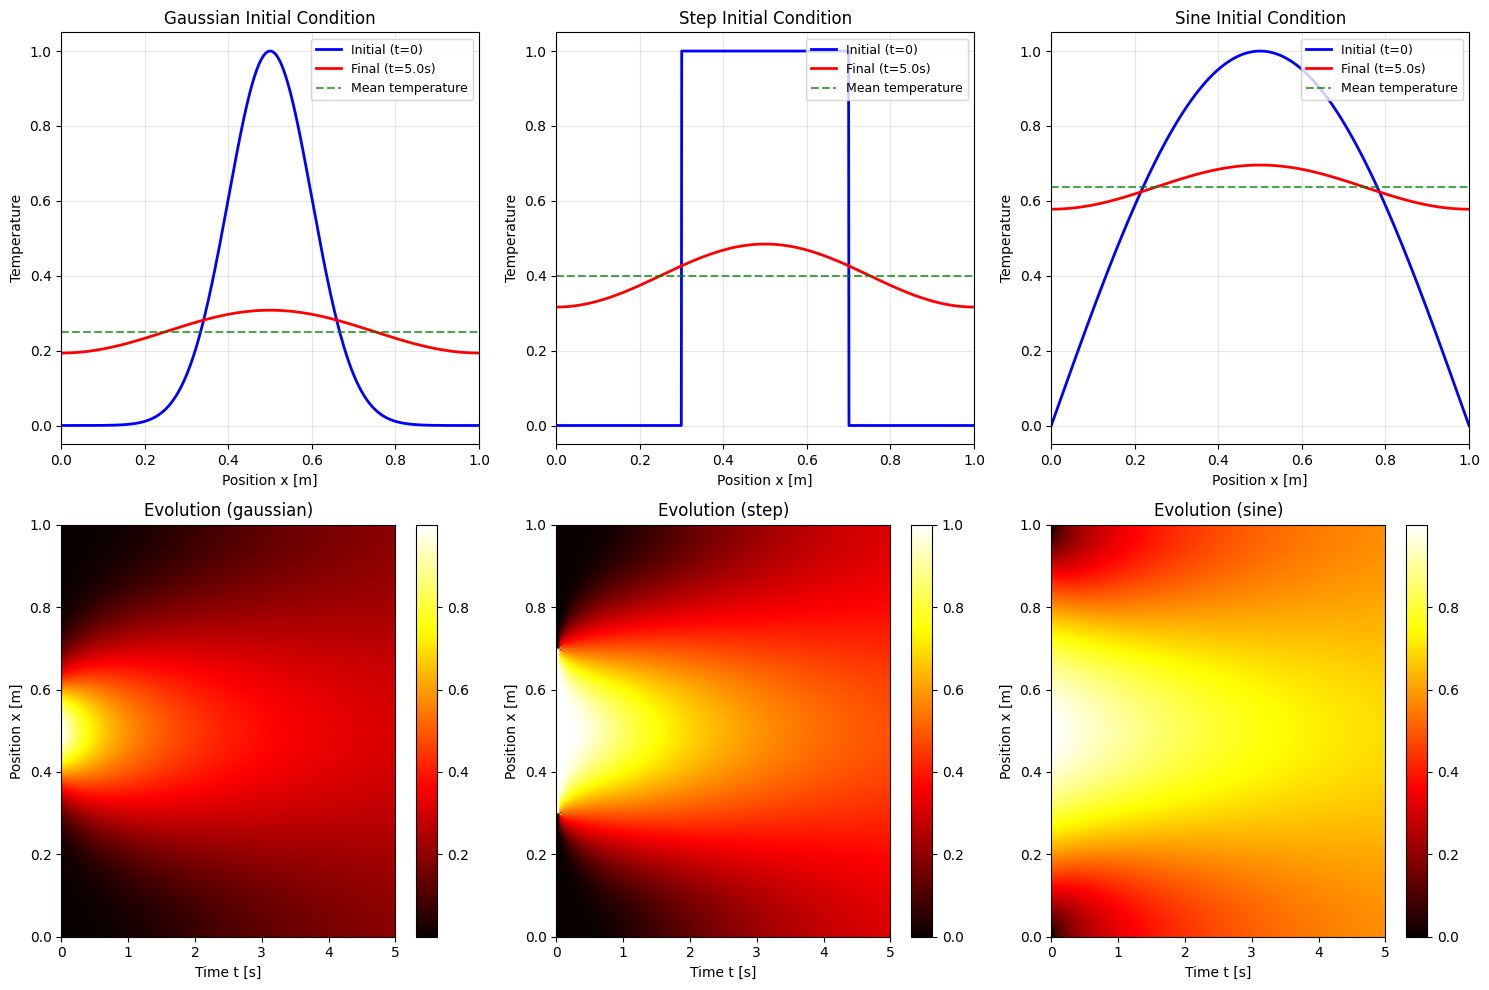

In [9]:
# Solve for different initial conditions
initial_conditions = ['gaussian', 'step', 'sine']
solutions = {}

for ic_type in initial_conditions:
    u0_ic = initial_condition(x, condition_type=ic_type)
    u_hist = solve_heat_equation(A, B, u0_ic, Nt, save_every=save_every)
    solutions[ic_type] = u_hist.cpu().numpy()

# Plot comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for col, ic_type in enumerate(initial_conditions):
    u_hist = solutions[ic_type]

    # Top row: Initial and final profiles
    ax = axes[0, col]
    ax.plot(x_np, u_hist[0], 'b-', linewidth=2, label='Initial (t=0)')
    ax.plot(x_np, u_hist[-1], 'r-', linewidth=2, label=f'Final (t={T_total}s)')
    ax.axhline(y=np.mean(u_hist[0]), color='g', linestyle='--',
               alpha=0.7, label='Mean temperature')
    ax.set_xlabel('Position x [m]')
    ax.set_ylabel('Temperature')
    ax.set_title(f'{ic_type.capitalize()} Initial Condition')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, L])

    # Bottom row: Space-time heatmaps
    ax = axes[1, col]
    im = ax.imshow(u_hist.T, aspect='auto', origin='lower',
                   extent=[0, T_total, 0, L], cmap='hot')
    ax.set_xlabel('Time t [s]')
    ax.set_ylabel('Position x [m]')
    ax.set_title(f'Evolution ({ic_type})')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

## 11. Performance: PyTorch vs NumPy

Let's compare the performance of our PyTorch implementation with a pure NumPy version. PyTorch can leverage GPU acceleration for significant speedups on larger problems.

In [10]:
import time

def solve_numpy(A_np, B_np, u0_np, Nt):
    """NumPy version of the solver."""
    u = u0_np.copy()
    for n in range(Nt):
        b = B_np @ u
        u = np.linalg.solve(A_np, b)
    return u

def solve_torch(A, B, u0, Nt):
    """PyTorch version of the solver."""
    u = u0.clone()
    for n in range(Nt):
        b = B @ u
        u = torch.linalg.solve(A, b)
    return u

# Convert to numpy
A_np = A.cpu().numpy()
B_np = B.cpu().numpy()
u0_np = u0.cpu().numpy()

# Benchmark
n_runs = 3
Nt_bench = 200

# NumPy timing
times_numpy = []
for _ in range(n_runs):
    start = time.perf_counter()
    _ = solve_numpy(A_np, B_np, u0_np, Nt_bench)
    times_numpy.append(time.perf_counter() - start)

# PyTorch CPU timing
times_torch_cpu = []
A_cpu = A.cpu()
B_cpu = B.cpu()
u0_cpu = u0.cpu()
for _ in range(n_runs):
    start = time.perf_counter()
    _ = solve_torch(A_cpu, B_cpu, u0_cpu, Nt_bench)
    times_torch_cpu.append(time.perf_counter() - start)

print(f"Benchmark results ({Nt_bench} time steps, {Nx} spatial points):")
print(f"  NumPy:        {np.mean(times_numpy)*1000:.2f} ms (std: {np.std(times_numpy)*1000:.2f} ms)")
print(f"  PyTorch CPU:  {np.mean(times_torch_cpu)*1000:.2f} ms (std: {np.std(times_torch_cpu)*1000:.2f} ms)")

# PyTorch GPU timing (if available)
if torch.cuda.is_available():
    A_gpu = A.cuda()
    B_gpu = B.cuda()
    u0_gpu = u0.cuda()

    # Warmup
    _ = solve_torch(A_gpu, B_gpu, u0_gpu, 10)
    torch.cuda.synchronize()

    times_torch_gpu = []
    for _ in range(n_runs):
        torch.cuda.synchronize()
        start = time.perf_counter()
        _ = solve_torch(A_gpu, B_gpu, u0_gpu, Nt_bench)
        torch.cuda.synchronize()
        times_torch_gpu.append(time.perf_counter() - start)

    print(f"  PyTorch GPU:  {np.mean(times_torch_gpu)*1000:.2f} ms (std: {np.std(times_torch_gpu)*1000:.2f} ms)")
    print(f"\n  GPU Speedup over NumPy: {np.mean(times_numpy)/np.mean(times_torch_gpu):.2f}x")

Benchmark results (200 time steps, 1000 spatial points):
  NumPy:        9316.69 ms (std: 954.14 ms)
  PyTorch CPU:  4601.41 ms (std: 299.28 ms)
  PyTorch GPU:  2005.53 ms (std: 14.66 ms)

  GPU Speedup over NumPy: 4.65x


## 12. Summary

In this notebook, we learned:

1. **The Heat Equation**: A fundamental PDE describing thermal diffusion

2. **Finite Difference Method**: Discretizing spatial derivatives using neighboring points

3. **Crank-Nicolson Scheme**: A stable, accurate implicit method for time-stepping that combines information from current and future time steps

4. **Neumann Boundary Conditions**: Representing insulated boundaries with zero heat flux, which conserves total heat

5. **PyTorch for Scientific Computing**: Using `torch.linalg.solve` for efficient linear system solving, with optional GPU acceleration

### Key Observations:
- Heat diffuses from hot regions to cold regions
- With insulated boundaries, the temperature eventually becomes uniform (equal to the initial average)
- The Crank-Nicolson method is unconditionally stable, allowing larger time steps
- Total heat is conserved (within numerical precision) due to Neumann BCs

### Extensions to Try:
- Add heat sources/sinks (non-homogeneous equation)
- Try Dirichlet boundary conditions (fixed temperature at ends)
- Extend to 2D or 3D domains
- Use adaptive time stepping
- Implement parallel-in-time methods